# Real-world Data Wrangling

In this project, you will apply the skills you acquired in the course to gather and wrangle real-world data with two datasets of your choice.

You will retrieve and extract the data, assess the data programmatically and visually, accross elements of data quality and structure, and implement a cleaning strategy for the data. You will then store the updated data into your selected database/data store, combine the data, and answer a research question with the datasets.

Throughout the process, you are expected to:

1. Explain your decisions towards methods used for gathering, assessing, cleaning, storing, and answering the research question
2. Write code comments so your code is more readable

## 1. Gather data

In this section, you will extract data using two different data gathering methods and combine the data. Use at least two different types of data-gathering methods.

### **1.1.** Problem Statement
In 2-4 sentences, explain the kind of problem you want to look at and the datasets you will be wrangling for this project.

Climate change is a global issue that varies significantly across countries and is influenced by both environmental and demographic factors. In this project, I examine country-level climate change indicators using a dataset obtained from Kaggle and combine it with country-level demographic data collected from a public webpage. By wrangling and integrating these datasets, the goal is to better understand patterns in climate-related metrics across countries while demonstrating data gathering, cleaning, and integration techniques.

Dataset Variables
    •   Country – the geographic unit of analysis used to merge datasets
	•	Year – the reporting year for climate indicators
	•	Climate indicators (e.g., temperature anomalies, emissions, or related metrics from the Kaggle dataset)
	•	Demographic variables (e.g., population or regional classification from the scraped dataset)


The dataset was pulled form Kaggle website

https://www.kaggle.com/datasets/tarunrm09/climate-change-indicators?resource=download



### **1.2.** Gather at least two datasets using two different data gathering methods

List of data gathering methods:

- Download data manually
- Programmatically downloading files
- Gather data by accessing APIs
- Gather and extract data from HTML files using BeautifulSoup
- Extract data from a SQL database

Each dataset must have at least two variables, and have greater than 500 data samples within each dataset.

For each dataset, briefly describe why you picked the dataset and the gathering method (2-3 full sentences), including the names and significance of the variables in the dataset. Show your work (e.g., if using an API to download the data, please include a snippet of your code). 

Load the dataset programmtically into this notebook.

#### **Dataset 1**

Type: *CLIMATE CHANGE INDICATORS* <BR>
How the data was gathered
The climate change indicators dataset was obtained from Kaggle using the Kaggle API, which allows programmatic and reproducible data access. The dataset was downloaded as a ZIP file and extracted locally, then loaded into the notebook using pandas for analysis.

Why this dataset was chosen
This dataset contains country-level climate indicators reported across multiple years, making it suitable for examining climate change patterns at a global scale. The presence of temporal and geographic variables also makes it ideal for merging with additional country-level demographic data collected from another source.


In [7]:
import pandas as pd
import os
os.getcwd()


'/Users/djromie/Data Project'

In [8]:
climate_df = pd.read_csv('climate-change-indicators.csv')
# Preview the dataa
climate_df.head()

,ObjectId,Country,ISO2,ISO3,Indicator,Unit,Source,CTS_Code,CTS_Name,CTS_Full_Descriptor,...,F2013,F2014,F2015,F2016,F2017,F2018,F2019,F2020,F2021,F2022
0,1,"Afghanistan, Islamic Rep. of",AF,AFG,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",...,1.281,0.456,1.093,1.555,1.540,1.544,0.910,0.498,1.327,2.012
1,2,Albania,AL,ALB,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",...,1.333,1.198,1.569,1.464,1.121,2.028,1.675,1.498,1.536,1.518
2,3,Algeria,DZ,DZA,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",...,1.192,1.690,1.121,1.757,1.512,1.210,1.115,1.926,2.330,1.688
3,4,American Samoa,AS,ASM,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",...,1.257,1.170,1.009,1.539,1.435,1.189,1.539,1.430,1.268,1.256
4,5,"Andorra, Principality of",AD,AND,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",...,0.831,1.946,1.690,1.990,1.925,1.919,1.964,2.562,1.533,3.243


#### Dataset 2

Type: *Beautiful Soup*

The second dataset was gathered by extracting an HTML table from a public webpage using BeautifulSoup and pandas. The dataset contains country-level population data, which provides useful demographic context for analyzing climate change indicators across countries.

Variables used

•	Country (renamed from “Location”) – represents the country or territory and serves as the key for merging with the climate change dataset<br>
	•	Population – total population of each country<br>
	•	Percentage of the world – shows each country’s share of the global population<br>
	•	Date – indicates the year or reference date for the population estimate<br>

In [17]:
import requests
import pandas as pd
from bs4 import BeautifulSoup

url = "https://en.wikipedia.org/wiki/List_of_countries_and_dependencies_by_population"

headers = {"User-Agent": "Mozilla/5.0"}
r = requests.get(url, headers=headers)
r.raise_for_status()

soup = BeautifulSoup(r.text, "html.parser")

# Count tables to avoid index errors
tables = soup.find_all("table")
print("Tables found by BeautifulSoup:", len(tables))

# Convert ALL tables found into DataFrames
dfs = pd.read_html(r.text)
print("Tables found by pandas:", len(dfs))

country_codes_df = dfs[0]   # pick the correct one
country_codes_df.head()

Tables found by BeautifulSoup: 3
Tables found by pandas: 3


/var/folders/8v/65qbz8y102j_byhqmt96lzq00000gn/T/ipykernel_1189/2194132788.py:18: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  dfs = pd.read_html(r.text)


,Location,Population,% of world,Date,Source (official or from the United Nations),Notes
0,World,8232000000,100%,13 Jun 2025,UN projection[1][3],NaN
1,India,1417492000,17.2%,1 Jul 2025,Official projection[4],[b]
2,China,1404890000,17.1%,31 Dec 2025,Official estimate[5],[c]
3,United States,341784857,4.2%,1 Jul 2025,Official estimate[6],[d]
4,Indonesia,284438782,3.5%,30 Jun 2025,National annual projection[7],NaN


In [19]:
# Rename Location column to Country for consistency
country_codes_df = country_codes_df.rename(columns={'Location': 'Country'})

country_codes_df.head()

,Country,Population,% of world,Date,Source (official or from the United Nations),Notes
0,World,8232000000,100%,13 Jun 2025,UN projection[1][3],NaN
1,India,1417492000,17.2%,1 Jul 2025,Official projection[4],[b]
2,China,1404890000,17.1%,31 Dec 2025,Official estimate[5],[c]
3,United States,341784857,4.2%,1 Jul 2025,Official estimate[6],[d]
4,Indonesia,284438782,3.5%,30 Jun 2025,National annual projection[7],NaN


In [ ]:
##The column labeled “Location” in the population dataset was renamed to “country” to ensure consistency with the climate change dataset and to enable accurate merging across datasets.

## 2. Assess data

Assess the data according to data quality and tidiness metrics using the report below.

List **two** data quality issues and **two** tidiness issues. Assess each data issue visually **and** programmatically, then briefly describe the issue you find.  **Make sure you include justifications for the methods you use for the assessment.**

### Quality Issue 1:

Issue:
Some climate indicator variables contain missing values, resulting in incomplete records.

How it was identified:
Programmatic inspection using .isnull().sum() revealed missing values in multiple columns.

Why this is a problem:
Missing data can reduce the reliability of analysis and may bias results if not handled appropriately.


In [22]:
#FILL IN - Inspecting the dataframe visually
climate_df.head(10)

,ObjectId,Country,ISO2,ISO3,Indicator,Unit,Source,CTS_Code,CTS_Name,CTS_Full_Descriptor,...,F2013,F2014,F2015,F2016,F2017,F2018,F2019,F2020,F2021,F2022
0,1,"Afghanistan, Islamic Rep. of",AF,AFG,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",...,1.281,0.456,1.093,1.555,1.540,1.544,0.910,0.498,1.327,2.012
1,2,Albania,AL,ALB,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",...,1.333,1.198,1.569,1.464,1.121,2.028,1.675,1.498,1.536,1.518
2,3,Algeria,DZ,DZA,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",...,1.192,1.690,1.121,1.757,1.512,1.210,1.115,1.926,2.330,1.688
3,4,American Samoa,AS,ASM,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",...,1.257,1.170,1.009,1.539,1.435,1.189,1.539,1.430,1.268,1.256
4,5,"Andorra, Principality of",AD,AND,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",...,0.831,1.946,1.690,1.990,1.925,1.919,1.964,2.562,1.533,3.243
5,6,Angola,AO,AGO,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",...,1.044,0.828,1.331,1.609,0.870,1.395,1.752,1.162,1.553,1.212
6,7,Anguilla,AI,AIA,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",...,0.770,0.814,1.051,1.125,0.960,0.664,0.843,1.224,0.893,0.839
7,8,Antigua and Barbuda,AG,ATG,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",...,0.783,0.744,1.035,1.097,0.958,0.627,0.797,1.131,0.862,0.770
8,9,Argentina,AR,ARG,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",...,0.442,0.951,0.957,0.488,1.095,0.878,0.760,1.123,1.031,0.643
9,10,"Armenia, Rep. of",AM,ARM,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",...,1.407,1.283,1.931,1.356,0.889,2.772,1.859,1.954,2.087,1.707


In [23]:
#FILL IN - Inspecting the dataframe Programmatic
climate_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225 entries, 0 to 224
Data columns (total 72 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ObjectId             225 non-null    int64  
 1   Country              225 non-null    object 
 2   ISO2                 223 non-null    object 
 3   ISO3                 225 non-null    object 
 4   Indicator            225 non-null    object 
 5   Unit                 225 non-null    object 
 6   Source               225 non-null    object 
 7   CTS_Code             225 non-null    object 
 8   CTS_Name             225 non-null    object 
 9   CTS_Full_Descriptor  225 non-null    object 
 10  F1961                188 non-null    float64
 11  F1962                189 non-null    float64
 12  F1963                188 non-null    float64
 13  F1964                188 non-null    float64
 14  F1965                188 non-null    float64
 15  F1966                192 non-null    flo

In [24]:
climate_df.isnull().sum()

ObjectId      0
Country       0
ISO2          2
ISO3          0
Indicator     0
             ..
F2018        12
F2019        12
F2020        13
F2021        12
F2022        12
Length: 72, dtype: int64

In [25]:
climate_df.duplicated().sum()

np.int64(0)

### Quality Issue 2: Validity


Some climate indicator columns are stored using inappropriate data types or formats (e.g., numeric values stored as objects or strings).

How it was identified:
Programmatic inspection using .info() showed that some columns expected to be numeric were stored as object types.

Why this is a problem:
Incorrect data types prevent numerical analysis and statistical operations without additional cleaning.


### Now for Beautiful soup

In [30]:
# Visual Check
country_codes_df.head(10)

,Country,Population,% of world,Date,Source (official or from the United Nations),Notes
0,World,8232000000,100%,13 Jun 2025,UN projection[1][3],NaN
1,India,1417492000,17.2%,1 Jul 2025,Official projection[4],[b]
2,China,1404890000,17.1%,31 Dec 2025,Official estimate[5],[c]
3,United States,341784857,4.2%,1 Jul 2025,Official estimate[6],[d]
4,Indonesia,284438782,3.5%,30 Jun 2025,National annual projection[7],NaN
5,Pakistan,241499431,2.9%,1 Mar 2023,2023 census result[8],[e]
6,Nigeria,223800000,2.7%,1 Jul 2023,Official projection[9],NaN
7,Brazil,213421037,2.6%,1 Jul 2025,Official estimate[10],NaN
8,Bangladesh,169828911,2.1%,14 Jun 2022,2022 census result[11],[f]
9,Russia,146028325,1.8%,1 Jan 2025,Official estimate[13],[g]


In [32]:
## Programmatic Check
country_codes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 6 columns):
 #   Column                                        Non-Null Count  Dtype 
---  ------                                        --------------  ----- 
 0   Country                                       240 non-null    object
 1   Population                                    240 non-null    int64 
 2   % of world                                    240 non-null    object
 3   Date                                          240 non-null    object
 4   Source (official or from the United Nations)  240 non-null    object
 5   Notes                                         33 non-null     object
dtypes: int64(1), object(5)
memory usage: 11.4+ KB


In [33]:
country_codes_df.isnull().sum()

Country                                           0
Population                                        0
% of world                                        0
Date                                              0
Source (official or from the United Nations)      0
Notes                                           207
dtype: int64

In [34]:
country_codes_df.duplicated().sum()

np.int64(0)

### Tidiness Issue 1: Each Variable forms a column


Issue:
The climate dataset stores multiple climate indicators in a wide format, with each indicator occupying a separate column.

How it was identified:
Visual inspection of the dataset structure showed many indicator columns rather than a standardized long format.

Why this is a problem:
Wide-format data can be difficult to analyze and compare across indicators, reducing analytical flexibility.


In [87]:
##Reviewing the structure of both datasets confirms that they contain different variables, record different types of observations, and are organized around different units of measurement.


### Tidiness Issue 2: Each Type of Observational Unit Forms a Table

Issue:
The climate dataset and the population dataset represent different observational units and are stored in separate tables.

How it was identified:
Visual inspection shows that climate indicators and population data are maintained in separate datasets.

Why this is a problem:
Keeping related observational units in separate tables prevents integrated analysis and violates tidy data principles.


## 3. Clean data
Clean the data to solve the 4 issues corresponding to data quality and tidiness found in the assessing step. **Make sure you include justifications for your cleaning decisions.**

After the cleaning for each issue, please use **either** the visually or programatical method to validate the cleaning was succesful.

At this stage, you are also expected to remove variables that are unnecessary for your analysis and combine your datasets. Depending on your datasets, you may choose to perform variable combination and elimination before or after the cleaning stage. Your dataset must have **at least** 4 variables after combining the data.

In [36]:
# FILL IN - Make copies of the datasets to ensure the raw dataframes 
# are not impacted
# Save Climate data
climate_df.to_csv("climate_df_raw.csv", index=False)

In [37]:
# Save raw Population data
country_codes_df.to_csv("country_codes_df_raw.csv", index=False)

In [44]:
# Make copies
cleaned_climate = climate_df.copy()
cleaned_country_codes = country_codes_df.copy()

### **Quality Issue 1: FILL IN**

In [45]:
## Visually showing file was not impacted
cleaned_climate.head()

,ObjectId,Country,ISO2,ISO3,Indicator,Unit,Source,CTS_Code,CTS_Name,CTS_Full_Descriptor,...,F2013,F2014,F2015,F2016,F2017,F2018,F2019,F2020,F2021,F2022
0,1,"Afghanistan, Islamic Rep. of",AF,AFG,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",...,1.281,0.456,1.093,1.555,1.540,1.544,0.910,0.498,1.327,2.012
1,2,Albania,AL,ALB,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",...,1.333,1.198,1.569,1.464,1.121,2.028,1.675,1.498,1.536,1.518
2,3,Algeria,DZ,DZA,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",...,1.192,1.690,1.121,1.757,1.512,1.210,1.115,1.926,2.330,1.688
3,4,American Samoa,AS,ASM,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",...,1.257,1.170,1.009,1.539,1.435,1.189,1.539,1.430,1.268,1.256
4,5,"Andorra, Principality of",AD,AND,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",...,0.831,1.946,1.690,1.990,1.925,1.919,1.964,2.562,1.533,3.243


In [89]:
## Visually showing file was not impacted
cleaned_country_codes.head()

,Country,Population,% of world,Date
0,World,8232000000,100.0,2025-06-13
1,India,1417492000,17.2,2025-07-01
2,China,1404890000,17.1,2025-12-31
3,United States,341784857,4.2,2025-07-01
4,Indonesia,284438782,3.5,2025-06-30


In [45]:
Climate dataset — Completeness (missing values)

Issue

Missing values found in key variables.

Cleaning

Pick the key columns you’ll use (country, year, and 1–2 climate indicators), then handle missingness.

In [46]:
# Example: keep only the key columns (update names after you confirm columns)
climate_clean = climate_df.copy()
key_cols = ['Country', 'Unit', 'Indicator', 'Source']
climate_clean = climate_clean[key_cols]

# Drop rows missing key values
climate_clean = climate_clean.dropna(subset=['Country'],)

In [57]:
cleaned_climate.head(10)

,ObjectId,Country,ISO2,ISO3,Indicator,Unit,Source,CTS_Code,CTS_Name,CTS_Full_Descriptor,...,F2013,F2014,F2015,F2016,F2017,F2018,F2019,F2020,F2021,F2022
0,1,"Afghanistan, Islamic Rep. of",AF,AFG,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",...,1.281,0.456,1.093,1.555,1.540,1.544,0.910,0.498,1.327,2.012
1,2,Albania,AL,ALB,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",...,1.333,1.198,1.569,1.464,1.121,2.028,1.675,1.498,1.536,1.518
2,3,Algeria,DZ,DZA,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",...,1.192,1.690,1.121,1.757,1.512,1.210,1.115,1.926,2.330,1.688
3,4,American Samoa,AS,ASM,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",...,1.257,1.170,1.009,1.539,1.435,1.189,1.539,1.430,1.268,1.256
4,5,"Andorra, Principality of",AD,AND,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",...,0.831,1.946,1.690,1.990,1.925,1.919,1.964,2.562,1.533,3.243
5,6,Angola,AO,AGO,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",...,1.044,0.828,1.331,1.609,0.870,1.395,1.752,1.162,1.553,1.212
6,7,Anguilla,AI,AIA,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",...,0.770,0.814,1.051,1.125,0.960,0.664,0.843,1.224,0.893,0.839
7,8,Antigua and Barbuda,AG,ATG,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",...,0.783,0.744,1.035,1.097,0.958,0.627,0.797,1.131,0.862,0.770
8,9,Argentina,AR,ARG,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",...,0.442,0.951,0.957,0.488,1.095,0.878,0.760,1.123,1.031,0.643
9,10,"Armenia, Rep. of",AM,ARM,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",...,1.407,1.283,1.931,1.356,0.889,2.772,1.859,1.954,2.087,1.707


In [72]:
cleaned_climate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225 entries, 0 to 224
Data columns (total 72 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ObjectId             225 non-null    int64  
 1   Country              225 non-null    object 
 2   ISO2                 223 non-null    object 
 3   ISO3                 225 non-null    object 
 4   Indicator            225 non-null    object 
 5   Unit                 225 non-null    object 
 6   Source               225 non-null    object 
 7   CTS_Code             225 non-null    object 
 8   CTS_Name             225 non-null    object 
 9   CTS_Full_Descriptor  225 non-null    object 
 10  F1961                188 non-null    float64
 11  F1962                189 non-null    float64
 12  F1963                188 non-null    float64
 13  F1964                188 non-null    float64
 14  F1965                188 non-null    float64
 15  F1966                192 non-null    flo

In [59]:
#show Population Data cleaned
cleaned_country_codes.head(10)

,Country,Population,% of world,Date,Source (official or from the United Nations),Notes
0,World,8232000000,100%,13 Jun 2025,UN projection[1][3],NaN
1,India,1417492000,17.2%,1 Jul 2025,Official projection[4],[b]
2,China,1404890000,17.1%,31 Dec 2025,Official estimate[5],[c]
3,United States,341784857,4.2%,1 Jul 2025,Official estimate[6],[d]
4,Indonesia,284438782,3.5%,30 Jun 2025,National annual projection[7],NaN
5,Pakistan,241499431,2.9%,1 Mar 2023,2023 census result[8],[e]
6,Nigeria,223800000,2.7%,1 Jul 2023,Official projection[9],NaN
7,Brazil,213421037,2.6%,1 Jul 2025,Official estimate[10],NaN
8,Bangladesh,169828911,2.1%,14 Jun 2022,2022 census result[11],[f]
9,Russia,146028325,1.8%,1 Jan 2025,Official estimate[13],[g]


In [61]:
## Convert percent of world ro numeric
cleaned_country_codes['% of world'] = (
    cleaned_country_codes['% of world']
    .astype(str)
    .str.replace('%', '', regex=False)
    .str.strip()
)

cleaned_country_codes['% of world'] = pd.to_numeric(
    cleaned_country_codes['% of world'],
    errors='coerce'
)

In [62]:
## Convert Date to Datetime
cleaned_country_codes['Date'] = pd.to_datetime(
   cleaned_country_codes['Date'],
    errors='coerce'
)

In [65]:
## Drop unnecessary columns
cleaned_country_codes = cleaned_country_codes[
    ['Country', 'Population', '% of world', 'Date']
]

In [66]:
# Validate 
cleaned_country_codes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Country     240 non-null    object        
 1   Population  240 non-null    int64         
 2   % of world  240 non-null    float64       
 3   Date        232 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 7.6+ KB


In [67]:
# Validate
cleaned_country_codes.head(10)

,Country,Population,% of world,Date
0,World,8232000000,100.0,2025-06-13
1,India,1417492000,17.2,2025-07-01
2,China,1404890000,17.1,2025-12-31
3,United States,341784857,4.2,2025-07-01
4,Indonesia,284438782,3.5,2025-06-30
5,Pakistan,241499431,2.9,2023-03-01
6,Nigeria,223800000,2.7,2023-07-01
7,Brazil,213421037,2.6,2025-07-01
8,Bangladesh,169828911,2.1,2022-06-14
9,Russia,146028325,1.8,2025-01-01


A separate cleaned copy of the population dataset (population_clean) was created to ensure all cleaning steps were applied without modifying the raw data. Cleaning steps included standardizing column names, correcting data types, and removing unnecessary variables.**

### **Quality Issue 2: FILL IN**

Justification: 
The water congener dataset was cleaned by removing records with missing transfer amounts, filtering out invalid negative values, and removing duplicate rows to ensure uniqueness. Location and time variables were retained to support merging with the weather dataset, while other non-essential columns were excluded to improve tidiness and focus the analysis.

### **Remove unnecessary variables and combine datasets**

Depending on the datasets, you can also peform the combination before the cleaning steps.

In [73]:
# Confirm merge key exists
print('Cleaned climate has country:', 'Country' in cleaned_climate.columns)
print('Country Codes has country:', 'Country' in cleaned_country_codes.columns)

# Standardize country formatting
cleaned_climate['Country'] = cleaned_climate['Country'].astype(str).str.strip()
cleaned_country_codes['Country'] = cleaned_country_codes['Country'].astype(str).str.strip()

Cleaned climate has country: True
Country Codes has country: True


/var/folders/8v/65qbz8y102j_byhqmt96lzq00000gn/T/ipykernel_1189/4243117434.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_country_codes['Country'] = cleaned_country_codes['Country'].astype(str).str.strip()


In [74]:
combined_df = pd.merge(
    cleaned_climate,
    cleaned_country_codes,
    on='Country',
    how='inner'
)

In [75]:
# Verify merge success
combined_df.head(10)

,ObjectId,Country,ISO2,ISO3,Indicator,Unit,Source,CTS_Code,CTS_Name,CTS_Full_Descriptor,...,F2016,F2017,F2018,F2019,F2020,F2021,F2022,Population,% of world,Date
0,2,Albania,AL,ALB,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",...,1.464,1.121,2.028,1.675,1.498,1.536,1.518,2363314,0.030,2025-01-01
1,3,Algeria,DZ,DZA,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",...,1.757,1.512,1.210,1.115,1.926,2.330,1.688,47400000,0.600,2025-01-01
2,6,Angola,AO,AGO,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",...,1.609,0.870,1.395,1.752,1.162,1.553,1.212,36604681,0.400,2024-09-19
3,8,Antigua and Barbuda,AG,ATG,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",...,1.097,0.958,0.627,0.797,1.131,0.862,0.770,103603,0.001,2024-01-01
4,9,Argentina,AR,ARG,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",...,0.488,1.095,0.878,0.760,1.123,1.031,0.643,46387098,0.600,2025-07-01
5,12,Australia,AU,AUS,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",...,1.172,1.141,1.129,1.422,1.416,0.629,0.754,27614400,0.300,2025-06-30
6,13,Austria,AT,AUT,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",...,2.096,1.741,2.524,2.370,2.315,1.395,2.498,9216459,0.100,2025-10-01
7,17,Bangladesh,BD,BGD,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",...,1.337,1.124,0.881,1.136,0.898,1.300,1.216,169828911,2.100,2022-06-14
8,18,Barbados,BB,BRB,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,267800,0.003,2022-12-31
9,20,Belgium,BE,BEL,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",...,1.882,1.731,2.196,2.081,2.572,1.203,2.807,11924322,0.100,2025-11-01


In [76]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132 entries, 0 to 131
Data columns (total 75 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ObjectId             132 non-null    int64         
 1   Country              132 non-null    object        
 2   ISO2                 130 non-null    object        
 3   ISO3                 132 non-null    object        
 4   Indicator            132 non-null    object        
 5   Unit                 132 non-null    object        
 6   Source               132 non-null    object        
 7   CTS_Code             132 non-null    object        
 8   CTS_Name             132 non-null    object        
 9   CTS_Full_Descriptor  132 non-null    object        
 10  F1961                118 non-null    float64       
 11  F1962                119 non-null    float64       
 12  F1963                118 non-null    float64       
 13  F1964                119 non-null  

In [77]:
## Validate merge success
combined_df.shape

(132, 75)

In [78]:
## Validate number of variables
combined_df.columns
len(combined_df.columns)

75

Justification: <br>

The climate and population datasets were merged using the country variable as a shared key to create a single, integrated dataset for analysis. Country values were standardized by stripping whitespace to improve matching accuracy. An inner join was used to retain only countries present in both datasets and avoid introducing unnecessary missing values.

## 4. Update your data store
Update your local database/data store with the cleaned data, following best practices for storing your cleaned data:

- Must maintain different instances / versions of data (raw and cleaned data)
- Must name the dataset files informatively
- Ensure both the raw and cleaned data is saved to your database/data store

In [79]:
# Save cleaned datasets
cleaned_climate.to_csv("cleaned_climate.csv", index=False)
cleaned_country_codes.to_csv("cleaned_country_codes.csv", index=False)

# Save final combined dataset
combined_df.to_csv("cleaned_climate_country_codes_combined.csv", index=False)

Cleaned versions of each dataset, as well as the final merged dataset, were saved locally using informative file names. Maintaining both raw and cleaned datasets ensures reproducibility and allows comparison between original and processed data.


## 5. Answer the research question

### **5.1:** Define and answer the research question 
Going back to the problem statement in step 1, use the cleaned data to answer the question you raised. Produce **at least** two visualizations using the cleaned data and explain how they help you answer the question.

*Research question:* FILL IN from answer to Step 1

In [ ]:
#Visual 1 - FILL IN
	showing climate indicator by country
	showing population vs climate indicator


In [81]:
year_col = "F2022"
year_col in combined_df.columns

True

In [82]:
combined_df[year_col] = pd.to_numeric(combined_df[year_col], errors="coerce")

<Figure size 640x480 with 0 Axes>

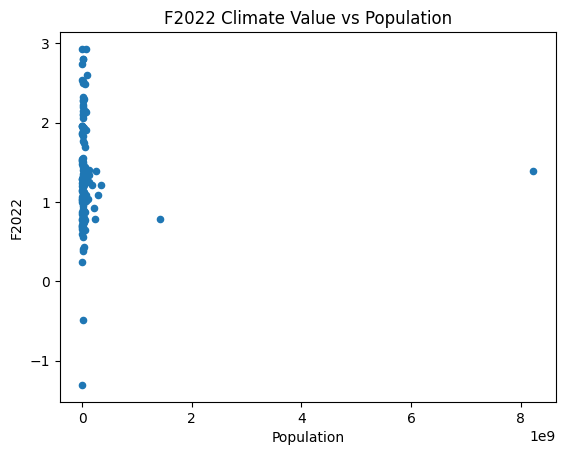

In [83]:
import matplotlib.pyplot as plt

plt.figure()
combined_df.plot(
    kind="scatter",
    x="Population",
    y=year_col,
    title=f"{year_col} Climate Value vs Population"
)
plt.show()

Answer to research question:<br>
This scatter plot shows how the selected climate indicator value for 2022 varies with country population. It helps identify whether higher-population countries tend to have higher or lower indicator values and highlights outliers.


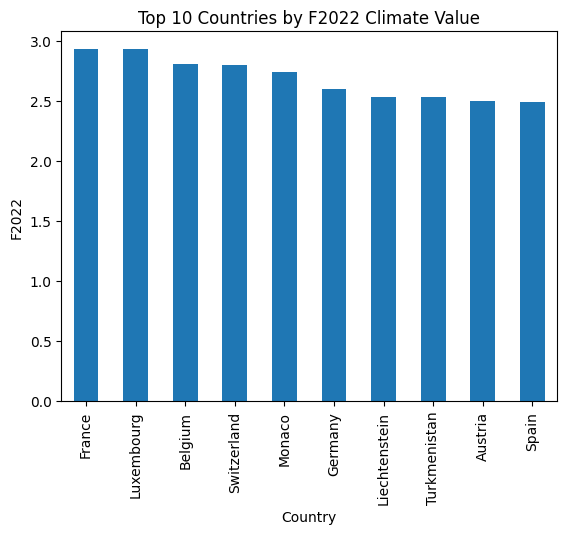

In [84]:
top10 = combined_df[['Country', year_col]].dropna().sort_values(year_col, ascending=False).head(10)

plt.figure()
top10.set_index('Country')[year_col].plot(kind="bar", title=f"Top 10 Countries by {year_col} Climate Value")
plt.ylabel(year_col)
plt.show()


This bar chart ranks the top 10 countries by the selected climate indicator value for 2022. It helps compare countries directly and highlights which countries have the highest reported values for the chosen indicator.


Using the merged dataset, I compared the climate indicator values for 2022 against country population. The visualizations show that the indicator values vary widely across countries, and population size alone does not fully explain the differences in climate indicator levels. The results also highlight outlier countries with unusually high (or low) indicator values for 2022.

### **5.2:** Reflection
In 2-4 sentences, if you had more time to complete the project, what actions would you take? For example, which data quality and structural issues would you look into further, and what research questions would you further explore?

*Answer:* <br>
If more time were available, additional data quality issues such as country name inconsistencies and differences in reporting coverage across years would be explored in greater detail. Further analysis could involve reshaping the climate dataset into a long format to better examine trends over time rather than focusing on a single year. Additional demographic or economic datasets could also be incorporated to explore how climate indicators relate to broader socioeconomic factors.
